# 4.9 IC Task 4.9 Part 2

# Table of Contents

#### Step 1 - Import libraries and dataframe

#### Step 3 - Create a histogram

#### Step 4 - Create a bar chart

#### Step 5 - Create a line chart

#### Step 6 - Create another line chart

#### Step 7 - Create a scatterplot

# Step 1 - Import libraries and dataframe

In [175]:
# Import analysis and visualization libraries

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [84]:
# Import latest, combined, up-to-date dataframe for Project

path = r'C:\Users\dirk8\CareerFoundry Projects\03-2025 Instacart Basket Analysis'
ords_prods_cust = pd.read_pickle(os.path.join(path, 'Data', 'Prepared Data', 'ords_prods_cust.pkl'))

In [85]:
# Check the output
ords_prods_cust.head()

,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,...,order_frequency_flag,first_name,last_name,gender,state_name,age,date_joined,number_dependents,family_status,income
0,2539329,1,1,2,8,NaN,196,1,0,Soda,...,Non-frequent customer,Linda,Nguyen,Female,Alabama,31,2019-02-17,3,married,40423
1,2539329,1,1,2,8,NaN,14084,2,0,Organic Unsweetened Vanilla Almond Milk,...,Non-frequent customer,Linda,Nguyen,Female,Alabama,31,2019-02-17,3,married,40423
2,2539329,1,1,2,8,NaN,12427,3,0,Original Beef Jerky,...,Non-frequent customer,Linda,Nguyen,Female,Alabama,31,2019-02-17,3,married,40423
3,2539329,1,1,2,8,NaN,26088,4,0,Aged White Cheddar Popcorn,...,Non-frequent customer,Linda,Nguyen,Female,Alabama,31,2019-02-17,3,married,40423
4,2539329,1,1,2,8,NaN,26405,5,0,XL Pick-A-Size Paper Towel Rolls,...,Non-frequent customer,Linda,Nguyen,Female,Alabama,31,2019-02-17,3,married,40423


In [184]:
# Check the output middle columns not visible in the output above

ords_prods_cust.iloc[0:2, 9:22]

,product_name,aisle_id,department_id,prices,price_range_loc,busiest_day,busiest_period_of_day,max_order,loyalty_flag,mean_price_per_order,spending_flag,median_days_since_prior_order,order_frequency_flag
0,Soda,77,7,9.0,Mid-range product,Regularly busy,Average orders,10,New customer,6.367797,Low spender,20.5,Non-frequent customer
1,Organic Unsweetened Vanilla Almond Milk,91,16,12.5,Mid-range product,Regularly busy,Average orders,10,New customer,6.367797,Low spender,20.5,Non-frequent customer


In [86]:
# Check the dimensions
ords_prods_cust.shape

(32399732, 31)

# Step 3 - Create a histogram

<Axes: ylabel='Frequency'>

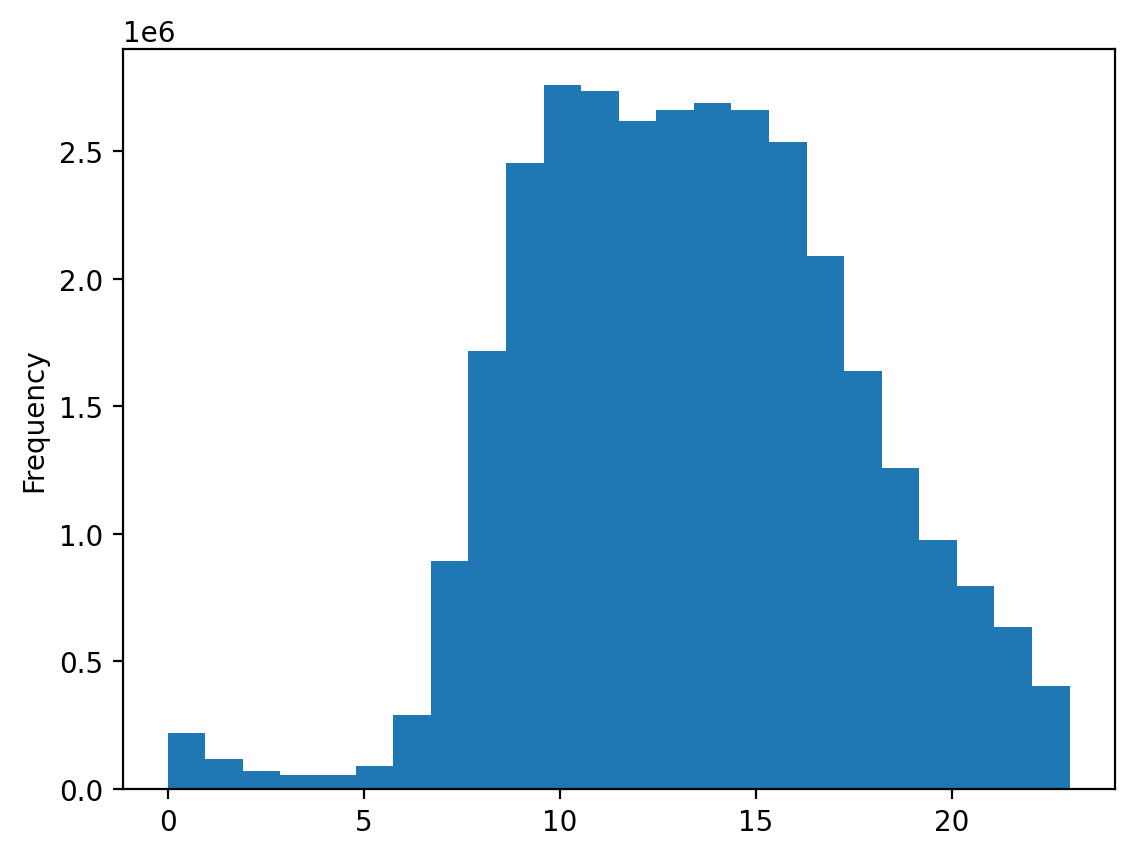

In [163]:
# Create a histogram of 'order_hour_of_day' column data

ords_prods_cust['order_hour_of_day'].plot.hist(bins = 24)

# Histogram shows high counts exceeding 2 million orders per hour from 9 am to 5 pm.  Outside of those hours, order count (frequency) drops dramatically.

__Comment on formatting python charts:  I spent 4+ hours trying dozens of workarounds with help from ChatGPT to do simple formatting of the x-axis (ticks and label), y-axis (label), chart size, chart title, histogram bars and get the resulting formatted to display.  The formatting workarounds, complicated by the LLM trying iterations of these using Pandas, Matplotlib and Seaborn libraries did work in some cases BUT it was impossible to get this jupyter notebook to show, display or otherwise make visible the resultant plot.  Instead, saving it to a .png file externally, then opening that file, does show the fully-formatted histogram.  So I will use that version .png file in the Project deliverables, but somehow the world's top LLM was unable to find a solution (nor was I) to show the fully-formatted histogram here.  There seem to be conflicts between the different visualization libraries imported, and/or the jupyter notebook environment, that for now are beyond what the course and Project appear to be teaching us.__

# DOCUMENTING BELOW THE VISUALIZATION CODE SCRIPT THAT DID WORK USING SEABORN-BASED FORMATTING, WHERE THE OUTPUT HISTOGRAM WAS SAVED EXTERNALLY INTO A USABLE, PROPERLY-FORMATTED CHART FOR PROJECT PURPOSES.  HOWEVER, THERE APPEARS TO BE NO WAY TO SHOW (DISPLAY) THE FORMATTED HISTOGRAM IN THIS JUPYTER NOTEBOOK ENVIRONMENT. AT LEAST CHATGPT COULD NOT FIND ANY WORKAROUND OVER 4+ HOURS OF ATTEMPTS.

In [173]:
# Comment: Plot with Seaborn, ensuring it uses the specified ax

# sns.histplot(ords_prods_cust['order_hour_of_day'], bins=24, kde=False, ax=ax, color='blue', edgecolor='black')

# Comment: Customize axes and title

# ax.set_xticks(np.arange(min(ords_prods_cust['order_hour_of_day']), 
#                        max(ords_prods_cust['order_hour_of_day']) + 1, 1))
# ax.set_xlabel("Hour of Day (military time)")
# ax.set_ylabel("Frequency (Count)")
# ax.set_title("Histogram of Orders per Hour of Day")

# Comment: Save the histogram externally, into a .png file that can be opened and displays exactly the intended chart

# fig.savefig("seaborn_histogram.png", dpi=300)

# Comment: Using plt.show() or any other output-targeting line of code for some reason will not output the histogram in jupyter notebook

# Step 4 - Create a bar chart

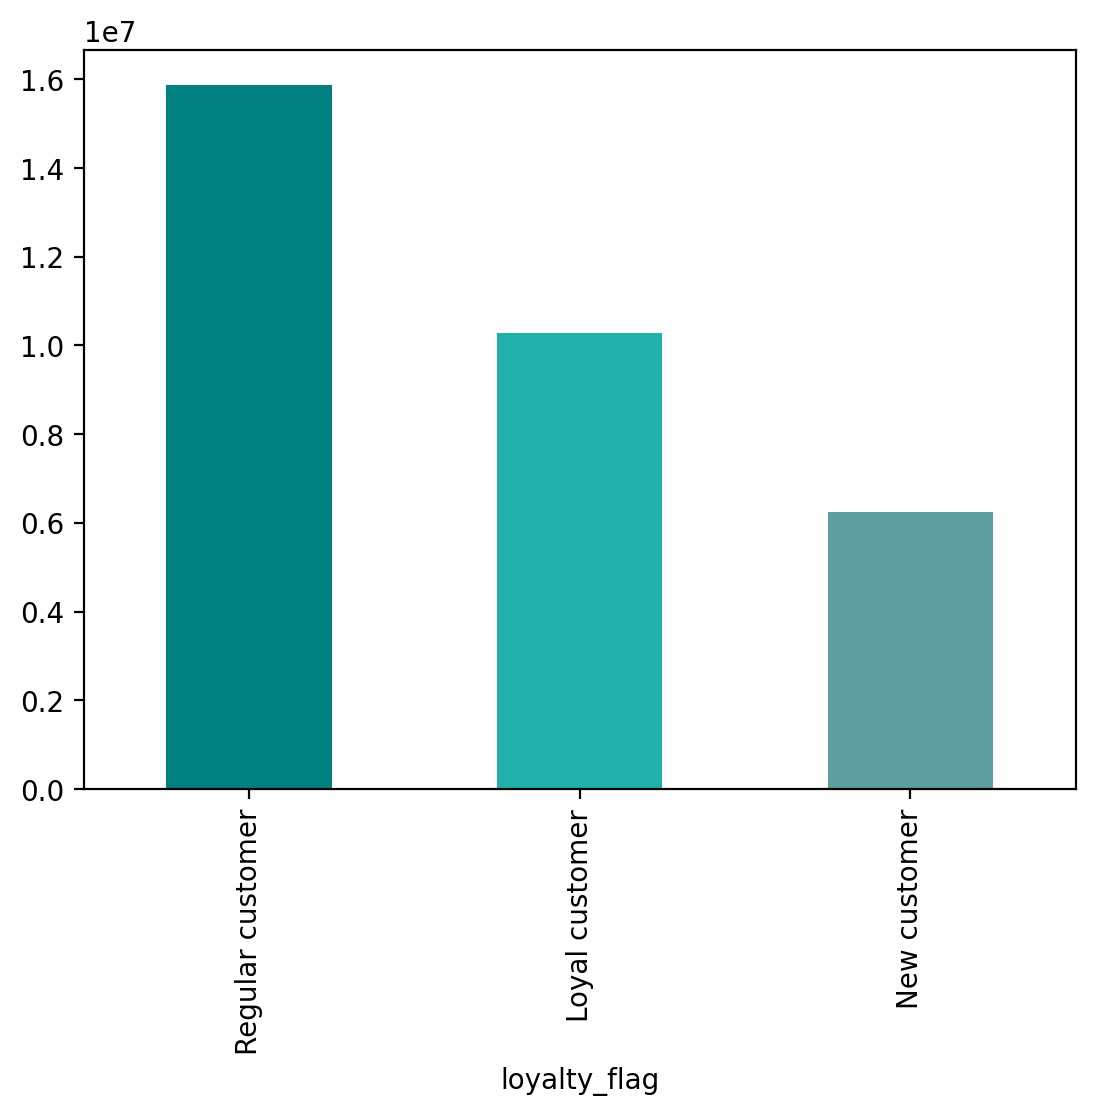

In [188]:
# Create a bar chart from the 'loyalty_flag" column

bar_loyalty = ords_prods_cust['loyalty_flag'].value_counts().plot.bar(color = ['teal', 'lightseagreen', 'cadetblue'])

In [192]:
# Export the bar chart image using figure.savefig()

bar_loyalty.figure.savefig(os.path.join(path, 'Analysis','Visualizations', 'bar_loyalty.png'))

# Step 5 - Create a line chart

In [195]:
# Step 5: Check whether there’s a difference in expenditure (the “prices” column) depending on the hour of the day.
# Step 5 Hint: To check this, you need to use an accurate sample for your line chart.

__Line charts, especially for our dataframe, use a lot of RAM.  Consequently, we need to create smaller subset dfs but based off randomized row selection for inclusion, to get a representative sample of the population.  This will show how the randomized samples are created, one can choose a 70/30 or 80/20 split in creating 2 samples.__

__SAMPLING DATA__

In [199]:
# We start by creating a seed for the random number generator, which can be any number
# Whatever number is chosen for the seed is used in the future to get the exact sequence of random numbers generated, for reproducibility purposes
# The random number generator (the function np.random.rand()) generates random numbers between 0 and 1
# The next line creates a list of boolean True/False values based on comparing the generated random numbers to 0.7 (proportion of df for one sample)
# This boolean list is assigned to a variable ("dev" in this example)

np.random.seed(4)
dev = np.random.rand(len(ords_prods_cust)) <= 0.7

In [200]:
# Check the output
dev

array([False,  True, False, ..., False,  True,  True])

In [201]:
# Check length
len(dev)

32399732

In [217]:
# Now we need to create 2 sample subset dfs using the created boolean list assigned to "dev"
# Store 70% of the sample in the dataframe big
# When you pass a variable containing a list of boolean values to the square brackets of a Pandas dataframe ...
# (cont.) ... it performs boolean indexing, selecting only the rows where the corresponding boolean value in the list is True

big = ords_prods_cust[dev]

In [219]:
# Store 30% of the sample in the dataframe small
# The tilde (~) means "not" whatever comes after, e.g. False (so here, it takes the False boolean values, which should make up 30% of the list

small = ords_prods_cust[~dev]

In [221]:
# Check length of population dataframe

len(ords_prods_cust)

32399732

In [223]:
# Check whether the lengths of the 70/30 sample subset dfs add up to match the length of the population df

len(big) + len(small)

32399732

In [225]:
# Save RAM further by creating a much smaller subset df with only the 2 variables needed to create the line chart

df_2 = small[['order_hour_of_day', 'prices']]

In [227]:
# Check the output
df_2.head(3)

,order_hour_of_day,prices
0,8,9.0
2,8,4.4
3,8,4.7


In [229]:
# Check the dimensions
df_2.shape

(9719609, 2)

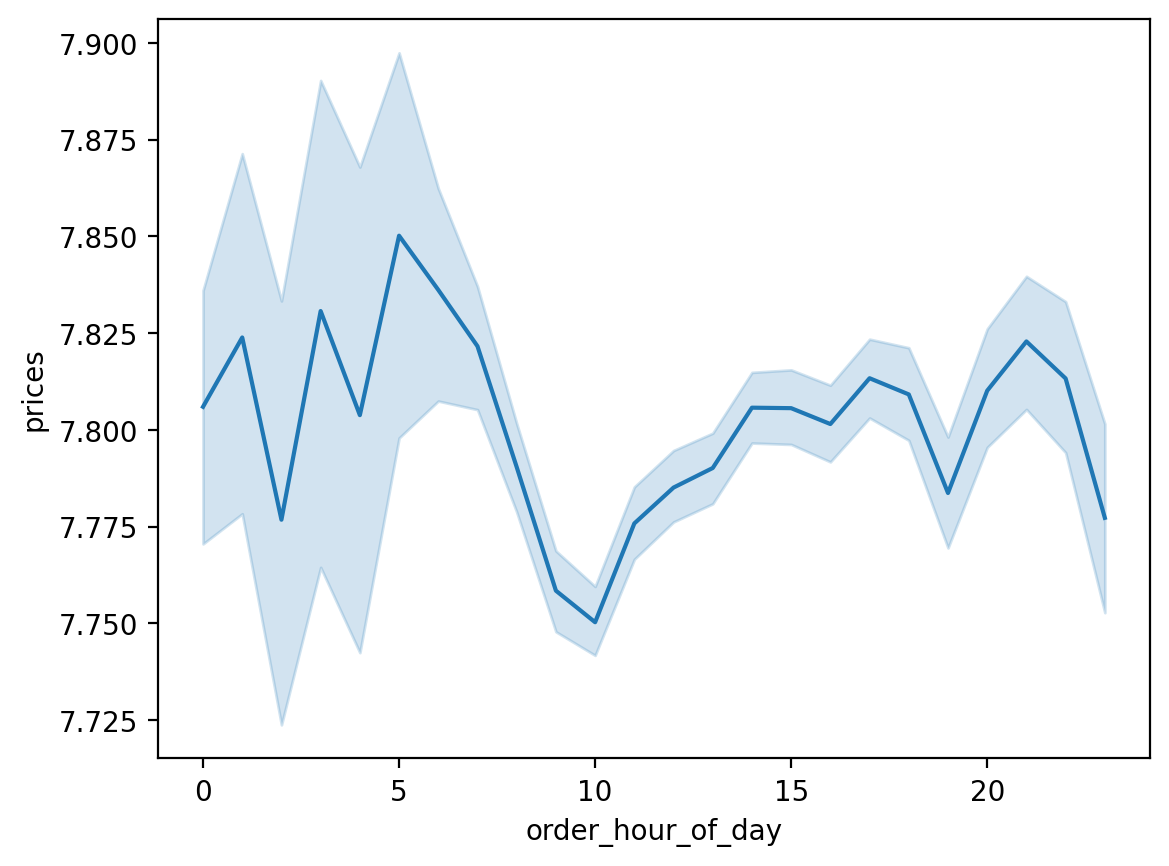

In [231]:
# Now we can create the line chart

line = sns.lineplot(data = df_2, x = 'order_hour_of_day', y = 'prices')

__Expenditure fluctuates throughout the day, does not seem to follow a distinct pattern.__

In [234]:
# Export the line chart

line.figure.savefig(os.path.join(path, 'Analysis','Visualizations', 'line_hour_prices.png'))

# Step 6 - Create another line chart

In [237]:
# Step 6: Now that you have information about customers, you need to conduct some exploratory analysis of customer demographics to inform ...
# (cont.) ... the targeted marketing campaigns. First, determine whether there’s a connection between age and family situation by creating ...
# (cont.) ... a line chart exploring the connections between age and number of dependents.

In [239]:
# Save RAM further by creating a much smaller subset df with only the 2 variables needed to create the line chart

df_3 = small[['age', 'number_dependents']]

In [241]:
# Check the output
df_3.head(3)

,age,number_dependents
0,31,3
2,31,3
3,31,3


In [243]:
# Check the dimensions
df_3.shape

(9719609, 2)

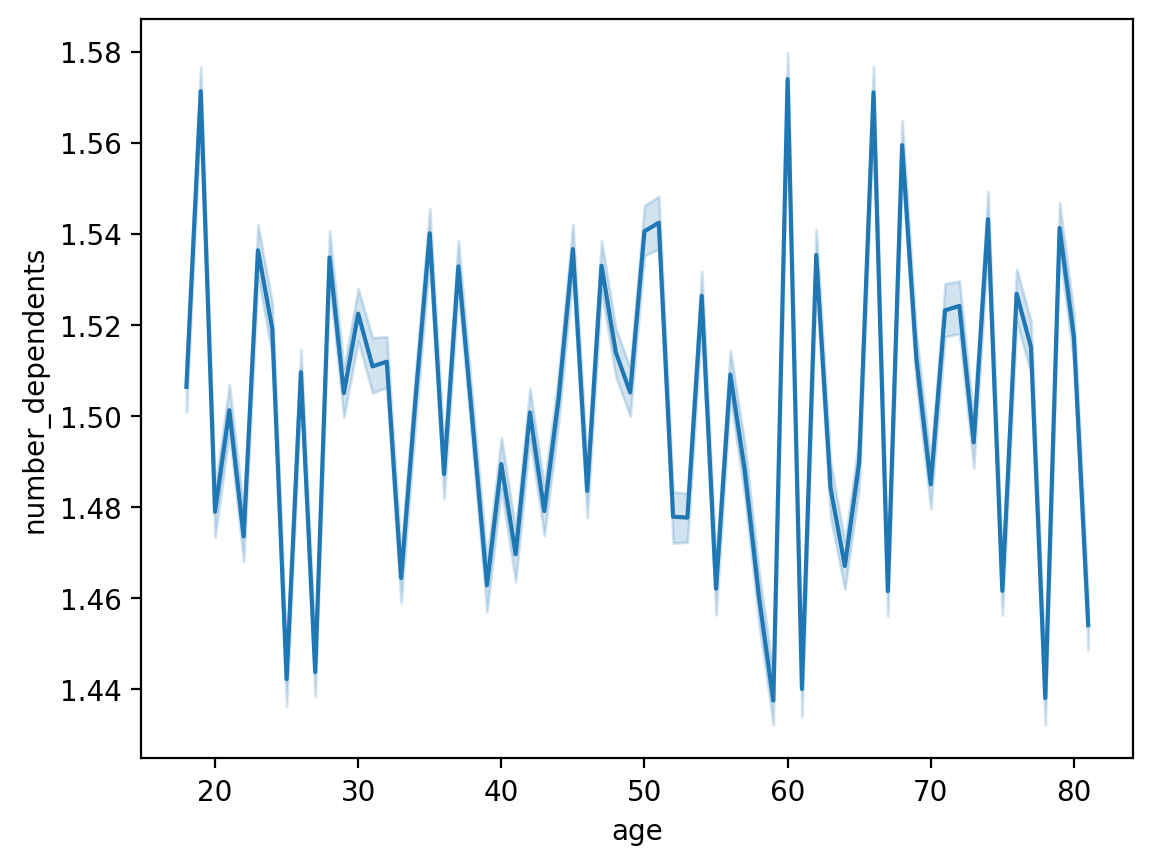

In [245]:
# We can create the line chart

line_age_dependents = sns.lineplot(data = df_3, x = 'age', y = 'number_dependents')

# There is no apparent connection between age and number of dependents.__

In [248]:
# Export the line chart

line_age_dependents.figure.savefig(os.path.join(path, 'Analysis','Visualizations', 'line_age_dependents.png'))

# Step 7 - Create a scatterplot

In [251]:
# Step 7: You’ll also need to explore whether there’s a connection between age and spending power (income).
# (cont.) .. To visualize this relationship, create a scatterplot using the sns.scatterplot() function.

In [257]:
# Create a scatterplot of 'age' vs 'income'
# A Google search suggests that Python scatterplots use more computer memory than line plots, which are memory hogs
# Thus, we will create a scatterplot from the subset df sample data to avoid crashing the laptop

In [259]:
# Save RAM further by creating a much smaller subset df with only the 2 variables needed to create the scatterplot

df_4 = small[['age', 'income']]

In [261]:
# Check the output
df_4.head(3)

,age,income
0,31,40423
2,31,40423
3,31,40423


In [263]:
# Check the dimensions
df_4.shape

(9719609, 2)

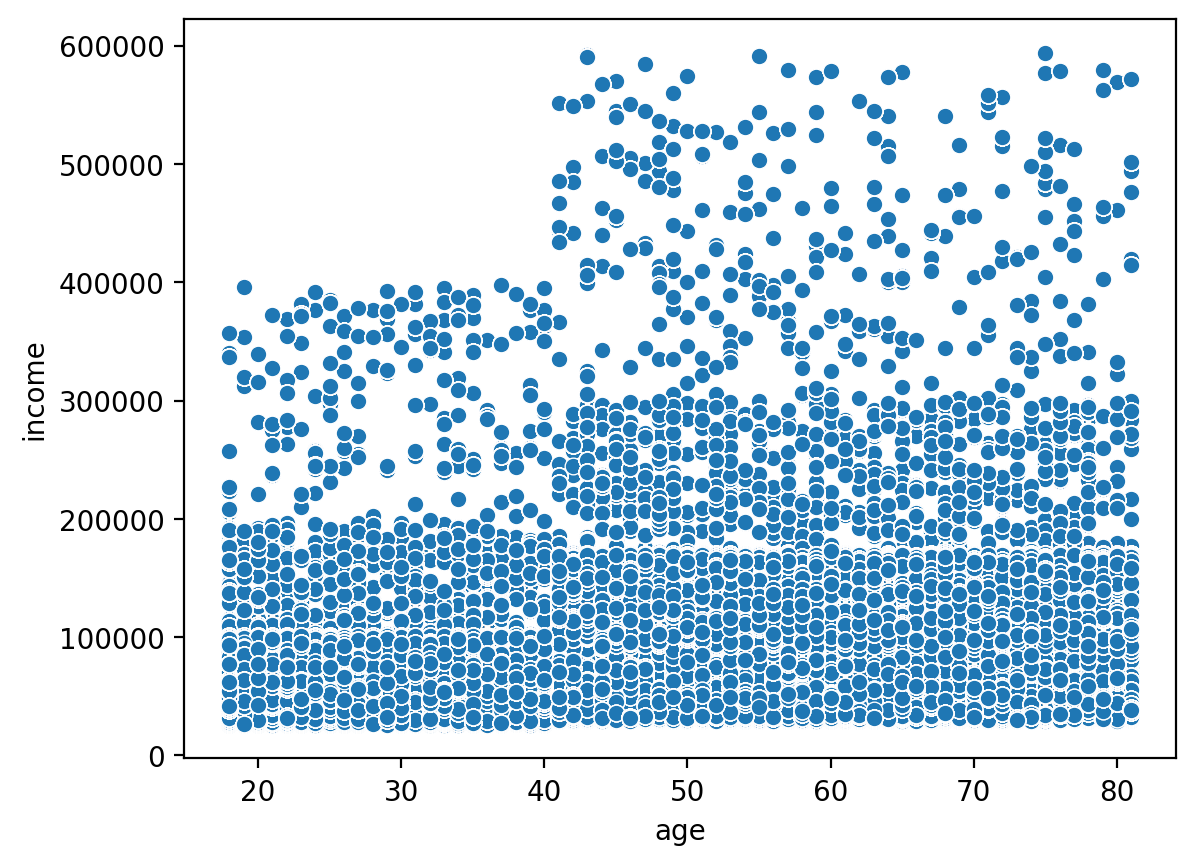

In [265]:
# We can create the scatterplot

scatterplot_age_income = sns.scatterplot(x = 'age', y = 'income',data = df_4)

# The scatterplot shows a large jump in income for certain segments of age groups starting in the early 40s

In [268]:
# Export the scatterplot

scatterplot_age_income.figure.savefig(os.path.join(path, 'Analysis','Visualizations', 'scatterplot_age_income.png'))

# Comment: No need to export the full dataframe "ords_prods_cust" because it was not modified. However, in case needed by further visualizations, it makes sense to export the 30% ("small") and 70% ("big") sample subset dataframes created in this session.

In [271]:
# Check the dimensions of "small" sample dataframe

small.shape

(9719609, 31)

In [273]:
# Export the "small" 30% sample dataframe as a pickle file

small.to_pickle(os.path.join(path, 'Data', 'Prepared Data', 'small_30_pct_sample.pkl'))

In [275]:
# Check the dimensions of "big" sample dataframe

big.shape

(22680123, 31)

In [277]:
# Export the "big" 70% sample dataframe as a pickle file

big.to_pickle(os.path.join(path, 'Data', 'Prepared Data', 'big_70_pct_sample.pkl'))